# 04 - E5 Diagnostico del baseline binario

**Objetivo:** diagnosticar el baseline binario entrenado en `03_E5_baseline_segmentacion_sagital.ipynb`, sin reentrenar ni modificar el modelo principal.

Este notebook analiza:

- evidencias exportadas por el baseline original;
- logits y probabilidades `sigmoid`;
- proporcion de foreground real y predicha;
- Dice e IoU para multiples thresholds;
- visualizaciones comparativas;
- diagnostico automatico y recomendaciones para el siguiente paso.

**Fuera de alcance:** entrenamiento nuevo, modificacion del modelo base, multiclase, axial, nnU-Net e integracion backend.

## 1. Instalacion e importacion de dependencias

In [1]:
!pip -q install SimpleITK scikit-image tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 17.4 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import json
import random
import warnings

import SimpleITK as sitk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.transform import resize
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("SimpleITK:", sitk.Version())
print("Dispositivo:", DEVICE)

PyTorch: 2.11.0+cpu
SimpleITK: SimpleITK Version: 2.5.5 (ITK 5.4)
Compiled: May 12 2026 17:19:38

Dispositivo: cpu


## 2. Montaje de Google Drive y definicion de rutas

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
PREPROCESS_ROOT = Path("/content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento")
BASELINE_ROOT = Path("/content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital")
FIGURES_ROOT = Path("/content/drive/MyDrive/PFI_MVP/figures")
DOCS_ROOT = Path("/content/drive/MyDrive/PFI_MVP/docs")

for path in [BASELINE_ROOT, FIGURES_ROOT, DOCS_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

MODEL_PATH = BASELINE_ROOT / "E5_simple_unet2d_baseline.pt"
CANDIDATES_CSV = PREPROCESS_ROOT / "E4_baseline_candidates_no_space.csv"
METRICS_CSV = BASELINE_ROOT / "E5_baseline_metrics.csv"
HISTORY_CSV = BASELINE_ROOT / "E5_training_history.csv"

print("PREPROCESS_ROOT:", PREPROCESS_ROOT)
print("BASELINE_ROOT:", BASELINE_ROOT)
print("FIGURES_ROOT:", FIGURES_ROOT)
print("DOCS_ROOT:", DOCS_ROOT)
print("MODEL_PATH:", MODEL_PATH)
print("CANDIDATES_CSV:", CANDIDATES_CSV)
print("METRICS_CSV:", METRICS_CSV)
print("HISTORY_CSV:", HISTORY_CSV)

PREPROCESS_ROOT: /content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento
BASELINE_ROOT: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital
FIGURES_ROOT: /content/drive/MyDrive/PFI_MVP/figures
DOCS_ROOT: /content/drive/MyDrive/PFI_MVP/docs
MODEL_PATH: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_simple_unet2d_baseline.pt
CANDIDATES_CSV: /content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento/E4_baseline_candidates_no_space.csv
METRICS_CSV: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_baseline_metrics.csv
HISTORY_CSV: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_training_history.csv


## 3. Carga de evidencias del baseline original

In [5]:
if not HISTORY_CSV.exists():
    raise FileNotFoundError(f"No existe history: {HISTORY_CSV}")
if not METRICS_CSV.exists():
    raise FileNotFoundError(f"No existe metrics: {METRICS_CSV}")
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"No existe modelo entrenado: {MODEL_PATH}")

history_df = pd.read_csv(HISTORY_CSV)
baseline_metrics_df = pd.read_csv(METRICS_CSV)

print("Modelo encontrado:", MODEL_PATH)
print("History rows:", len(history_df))
print("Metric rows:", len(baseline_metrics_df))

display(history_df)
display(baseline_metrics_df)

print("Dice promedio baseline:", baseline_metrics_df["dice"].mean())
print("IoU promedio baseline:", baseline_metrics_df["iou"].mean())

Modelo encontrado: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_simple_unet2d_baseline.pt
History rows: 5
Metric rows: 4


,epoch,train_loss,train_dice,train_iou,val_loss,val_dice,val_iou
0,1,1.410279,0.412234,0.274764,1.516457,0.23636,0.134354
1,2,1.334607,0.466452,0.317234,1.546521,0.23636,0.134354
2,3,1.303834,0.475645,0.325810,1.589540,0.23636,0.134354
3,4,1.277783,0.485407,0.333762,1.645868,0.23636,0.134354
4,5,1.232016,0.505294,0.349966,1.732431,0.23636,0.134354


,case_id,slice_index,dice,iou,source_image_path,source_mask_path
0,88_t1,8,0.261437,0.150375,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...
1,86_t1,11,0.236549,0.134140,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...
2,3_t1,8,0.261045,0.150116,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...
3,67_t1,11,0.186407,0.102783,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...


Dice promedio baseline: 0.2363595403730869
IoU promedio baseline: 0.1343536376953125


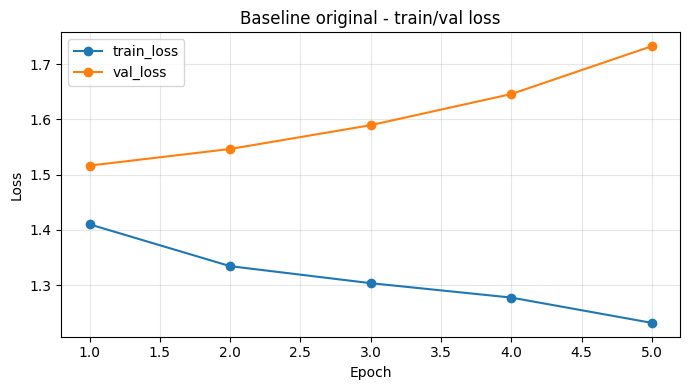

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
ax.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Baseline original - train/val loss")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## 4. Reconstruccion minima del modelo

In [7]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SimpleUNet2D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=16):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base_channels)
        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_channels * 4, base_channels * 8)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4)
        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2)
        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels)

        self.out = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)


checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model = SimpleUNet2D().to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Checkpoint keys:", checkpoint.keys())
print("target_size checkpoint:", checkpoint.get("target_size"))
print("sagittal_axis checkpoint:", checkpoint.get("sagittal_axis"))
print("modality_filter checkpoint:", checkpoint.get("modality_filter"))
print("n_cases checkpoint:", checkpoint.get("n_cases"))

Checkpoint keys: dict_keys(['model_state_dict', 'history', 'target_size', 'sagittal_axis', 'modality_filter', 'n_cases'])
target_size checkpoint: (256, 256)
sagittal_axis checkpoint: 2
modality_filter checkpoint: t1
n_cases checkpoint: 20


## 5. Reconstruccion reproducible del conjunto de validacion

In [8]:
MODALITY_FILTER = checkpoint.get("modality_filter", "t1")
N_CASES = int(checkpoint.get("n_cases", 20))
SAGITTAL_AXIS = int(checkpoint.get("sagittal_axis", 2))
TARGET_SIZE = tuple(checkpoint.get("target_size", (256, 256)))
BATCH_SIZE = 1

candidates_df = pd.read_csv(CANDIDATES_CSV)

def infer_case_modality(row):
    text = " ".join(str(v).lower() for v in row.values)
    if "t2" in text:
        return "t2"
    if "t1" in text:
        return "t1"
    return "unknown"


work_df = candidates_df.copy()
if "modality" not in work_df.columns:
    work_df["modality"] = work_df.apply(infer_case_modality, axis=1)

if MODALITY_FILTER != "both":
    filtered_df = work_df[work_df["modality"].str.lower().eq(MODALITY_FILTER)].copy()
else:
    filtered_df = work_df.copy()

selected_df = filtered_df.sample(n=min(N_CASES, len(filtered_df)), random_state=SEED).reset_index(drop=True)

print("Candidatos totales:", len(candidates_df))
print("Filtro modalidad:", MODALITY_FILTER)
print("Candidatos filtrados:", len(filtered_df))
print("Casos seleccionados reconstruidos:", len(selected_df))
print("Nota: se reconstruye la misma seleccion si el notebook 03 uso SEED=42, sample(random_state=42) y random_split con SEED=42.")
display(selected_df.head())

Candidatos totales: 406
Filtro modalidad: t1
Candidatos filtrados: 196
Casos seleccionados reconstruidos: 20
Nota: se reconstruye la misma seleccion si el notebook 03 uso SEED=42, sample(random_state=42) y random_split con SEED=42.


,case_id,image_path,mask_path,image_shape_zyx,mask_shape_zyx,same_shape,image_spacing_xyz,mask_spacing_xyz,same_spacing,image_origin_xyz,...,image_mean,image_p01,image_p05,image_p50,image_p95,image_p99,mask_unique_labels,mask_label_voxel_counts,mask_nonzero_voxels,modality
0,34_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(17, 512, 512)","(17, 512, 512)",True,"(0.5859375, 0.5859375, 3.29999995231625)","(0.5859375, 0.5859375, 3.29999995231625)",True,"(25.310411453247, -173.97094345166, 208.794188...",...,67.792228,0.0,2.0,46.0,237.0,381.0,"[0, 1, 2, 3, 4, 5, 6, 7, 100, 201, 202, 203, 2...","{""0"": 4067496, ""1"": 45569, ""2"": 46824, ""3"": 47...",388952,t1
1,237_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(611, 646, 18)","(611, 646, 18)",True,"(4.397158886379771, 0.47702580399344185, 0.504...","(4.397158886379771, 0.47702580399344185, 0.504...",True,"(-35.357652670789285, -105.48043042480317, -15...",...,223.040949,-1000.0,-1000.0,-42.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 100, 201, 202, 203, 204,...","{""0"": 6853402, ""1"": 29378, ""2"": 28073, ""3"": 28...",251306,t1
2,11_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(590, 512, 21)","(590, 512, 21)",True,"(3.312444001646348, 0.5859375000028706, 0.5109...","(3.312444001646348, 0.5859375000028706, 0.5109...",True,"(-48.262890541576496, -151.08433532714844, -52...",...,577.450562,-1000.0,-1000.0,405.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 100, 201, 202, 203...","{""0"": 5904536, ""1"": 49436, ""2"": 48522, ""3"": 46...",439144,t1
3,192_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(448, 448, 24)","(448, 448, 24)",True,"(3.2999548400246894, 0.625, 0.6252388405966087)","(3.2999548400246903, 0.6250000000000001, 0.625...",True,"(-33.95211536991131, -100.35483169555, -118.04...",...,440.976977,-1000.0,-1000.0,212.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 100, 201, 202, 203, 204,...","{""0"": 4583424, ""1"": 34950, ""2"": 35448, ""3"": 34...",233472,t1
4,52_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(17, 512, 512)","(17, 512, 512)",True,"(0.5859375, 0.5859375, 3.299999961969196)","(0.5859375, 0.5859375, 3.299999961969196)",True,"(40.290493751358, -169.61259079053, 354.605962...",...,182.957843,0.0,2.0,174.0,375.0,451.0,"[0, 1, 2, 3, 4, 5, 6, 7, 100, 201, 202, 203, 2...","{""0"": 4051205, ""1"": 45458, ""2"": 51726, ""3"": 53...",405243,t1


In [9]:
def resolve_path(value):
    return Path(str(value))


def get_case_paths(row):
    image_candidates = ["image_path", "source_image_path", "image", "img_path"]
    mask_candidates = ["mask_path", "source_mask_path", "mask", "seg_path"]

    image_path = None
    mask_path = None

    for column in image_candidates:
        if column in row and pd.notna(row[column]):
            image_path = resolve_path(row[column])
            break

    for column in mask_candidates:
        if column in row and pd.notna(row[column]):
            mask_path = resolve_path(row[column])
            break

    if image_path is None or mask_path is None:
        raise ValueError("No se encontraron columnas de path para imagen/mascara en el CSV de E4.")

    return image_path, mask_path


def read_mha(path: Path):
    itk_image = sitk.ReadImage(str(path))
    array = sitk.GetArrayFromImage(itk_image)
    return itk_image, array


def robust_percentile_normalize(image_array, p_low=1, p_high=99, eps=1e-8):
    image_float = image_array.astype(np.float32)
    low, high = np.percentile(image_float, [p_low, p_high])
    clipped = np.clip(image_float, low, high)
    if np.isclose(high, low):
        normalized = np.zeros_like(clipped, dtype=np.float32)
    else:
        normalized = (clipped - low) / (high - low + eps)
    return normalized.astype(np.float32)


def binarize_mask(mask_array):
    return (mask_array > 0).astype(np.float32)


def representative_slice_index(mask_array, axis=2):
    if np.count_nonzero(mask_array) == 0:
        return int(mask_array.shape[axis] // 2)
    reduce_axes = tuple(ax for ax in range(mask_array.ndim) if ax != axis)
    area_by_slice = np.sum(mask_array > 0, axis=reduce_axes)
    return int(np.argmax(area_by_slice))


def take_slice(array, axis, index):
    return np.take(array, indices=index, axis=axis)


def resize_slice(array_2d, target_size=TARGET_SIZE, order=1):
    return resize(
        array_2d,
        output_shape=target_size,
        order=order,
        preserve_range=True,
        anti_aliasing=(order != 0),
    ).astype(np.float32)


def preprocess_case(row, axis=SAGITTAL_AXIS, target_size=TARGET_SIZE):
    image_path, mask_path = get_case_paths(row)
    itk_image, image = read_mha(image_path)
    itk_mask, mask = read_mha(mask_path)

    if image.shape != mask.shape:
        raise ValueError(f"Shape incompatible: image={image.shape}, mask={mask.shape}")

    image_norm = robust_percentile_normalize(image)
    mask_bin = binarize_mask(mask)
    slice_index = representative_slice_index(mask_bin, axis=axis)

    image_slice = take_slice(image_norm, axis, slice_index)
    mask_slice = take_slice(mask_bin, axis, slice_index)

    image_slice = resize_slice(image_slice, target_size=target_size, order=1)
    mask_slice = resize_slice(mask_slice, target_size=target_size, order=0)
    mask_slice = (mask_slice > 0.5).astype(np.float32)

    case_id = row["case_id"] if "case_id" in row else image_path.stem

    return {
        "case_id": str(case_id),
        "image": image_slice[None, ...].astype(np.float32),
        "mask": mask_slice[None, ...].astype(np.float32),
        "slice_index": int(slice_index),
        "spacing": tuple(float(x) for x in itk_image.GetSpacing()),
        "source_image_path": str(image_path),
        "source_mask_path": str(mask_path),
    }


class SpiderSagittalSliceDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe.reset_index(drop=True)
        self.cache = {}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        if index not in self.cache:
            self.cache[index] = preprocess_case(self.dataframe.iloc[index])
        item = self.cache[index]
        return {
            "image": torch.from_numpy(item["image"]).float(),
            "mask": torch.from_numpy(item["mask"]).float(),
            "case_id": item["case_id"],
            "slice_index": item["slice_index"],
            "source_image_path": item["source_image_path"],
            "source_mask_path": item["source_mask_path"],
        }


dataset = SpiderSagittalSliceDataset(selected_df)
val_size = max(1, int(round(0.2 * len(dataset))))
train_size = len(dataset) - val_size
generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train reconstruido:", len(train_dataset))
print("Validation reconstruido:", len(val_dataset))

preview = next(iter(val_loader))
print("Image shape:", preview["image"].shape)
print("Mask shape:", preview["mask"].shape)
print("Mask unique:", torch.unique(preview["mask"]))

Train reconstruido: 16
Validation reconstruido: 4
Image shape: torch.Size([1, 1, 256, 256])
Mask shape: torch.Size([1, 1, 256, 256])
Mask unique: tensor([0., 1.])


## 6. Diagnostico de logits y probabilidades

In [10]:
def dice_iou_numpy(pred_mask, gt_mask, eps=1e-7):
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)
    intersection = np.logical_and(pred, gt).sum()
    pred_sum = pred.sum()
    gt_sum = gt.sum()
    union = np.logical_or(pred, gt).sum()
    dice = (2.0 * intersection + eps) / (pred_sum + gt_sum + eps)
    iou = (intersection + eps) / (union + eps)
    return float(dice), float(iou)


probability_rows = []
inference_cache = []

model.eval()
for batch in tqdm(val_loader, desc="Inferencia validacion"):
    with torch.no_grad():
        images = batch["image"].to(DEVICE)
        masks = batch["mask"].to(DEVICE)
        logits = model(images)
        probs = torch.sigmoid(logits)

    image_np = images.detach().cpu().numpy()
    mask_np = masks.detach().cpu().numpy()
    logits_np = logits.detach().cpu().numpy()
    probs_np = probs.detach().cpu().numpy()

    row = {
        "case_id": batch["case_id"][0],
        "slice_index": int(batch["slice_index"][0]),
        "logits_min": float(logits_np.min()),
        "logits_max": float(logits_np.max()),
        "logits_mean": float(logits_np.mean()),
        "probs_min": float(probs_np.min()),
        "probs_max": float(probs_np.max()),
        "probs_mean": float(probs_np.mean()),
        "probs_std": float(probs_np.std()),
        "gt_foreground_ratio": float((mask_np > 0.5).mean()),
        "source_image_path": batch["source_image_path"][0],
        "source_mask_path": batch["source_mask_path"][0],
    }
    probability_rows.append(row)

    inference_cache.append({
        "case_id": batch["case_id"][0],
        "slice_index": int(batch["slice_index"][0]),
        "image": image_np[0, 0],
        "mask": mask_np[0, 0],
        "logits": logits_np[0, 0],
        "probs": probs_np[0, 0],
    })

probability_stats_df = pd.DataFrame(probability_rows)
probability_stats_csv_path = BASELINE_ROOT / "E5_diagnostic_probability_stats.csv"
probability_stats_df.to_csv(probability_stats_csv_path, index=False)

print("CSV stats probabilidades:", probability_stats_csv_path)
display(probability_stats_df)

Inferencia validacion:   0%|          | 0/4 [00:00<?, ?it/s]

CSV stats probabilidades: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_diagnostic_probability_stats.csv


,case_id,slice_index,logits_min,logits_max,logits_mean,probs_min,probs_max,probs_mean,probs_std,gt_foreground_ratio,source_image_path,source_mask_path
0,88_t1,8,0.092476,1.054386,0.612793,0.523102,0.741616,0.647226,0.045998,0.150375,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...
1,86_t1,11,0.092471,1.096950,0.632931,0.523101,0.749688,0.651219,0.054910,0.134140,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...
2,3_t1,8,0.100710,1.113906,0.662156,0.525156,0.752857,0.658169,0.048633,0.150116,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...
3,67_t1,11,0.096675,1.107120,0.697766,0.524150,0.751592,0.666398,0.043603,0.102783,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...


## 7. Diagnostico de foreground por threshold

In [11]:
THRESHOLDS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

threshold_rows = []
for item in inference_cache:
    gt = item["mask"] > 0.5
    probs = item["probs"]

    for threshold in THRESHOLDS:
        pred = probs >= threshold
        dice, iou = dice_iou_numpy(pred, gt)
        threshold_rows.append({
            "case_id": item["case_id"],
            "slice_index": item["slice_index"],
            "threshold": float(threshold),
            "gt_foreground_ratio": float(gt.mean()),
            "pred_foreground_ratio": float(pred.mean()),
            "dice": dice,
            "iou": iou,
            "gt_positive_pixels": int(gt.sum()),
            "pred_positive_pixels": int(pred.sum()),
        })

threshold_diagnostics_df = pd.DataFrame(threshold_rows)
threshold_diagnostics_csv_path = BASELINE_ROOT / "E5_threshold_diagnostics.csv"
threshold_diagnostics_df.to_csv(threshold_diagnostics_csv_path, index=False)

print("CSV diagnostico thresholds:", threshold_diagnostics_csv_path)
display(threshold_diagnostics_df)

CSV diagnostico thresholds: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_threshold_diagnostics.csv


,case_id,slice_index,threshold,gt_foreground_ratio,pred_foreground_ratio,dice,iou,gt_positive_pixels,pred_positive_pixels
0,88_t1,8,0.1,0.150375,1.000000,2.614370e-01,1.503754e-01,9855,65536
1,88_t1,8,0.2,0.150375,1.000000,2.614370e-01,1.503754e-01,9855,65536
2,88_t1,8,0.3,0.150375,1.000000,2.614370e-01,1.503754e-01,9855,65536
3,88_t1,8,0.4,0.150375,1.000000,2.614370e-01,1.503754e-01,9855,65536
4,88_t1,8,0.5,0.150375,1.000000,2.614370e-01,1.503754e-01,9855,65536
5,88_t1,8,0.6,0.150375,0.844360,3.022810e-01,1.780512e-01,9855,55336
6,88_t1,8,0.7,0.150375,0.139847,3.766562e-01,2.320249e-01,9855,9165
7,88_t1,8,0.8,0.150375,0.000000,1.014713e-11,1.014713e-11,9855,0
8,88_t1,8,0.9,0.150375,0.000000,1.014713e-11,1.014713e-11,9855,0
9,86_t1,11,0.1,0.134140,1.000000,2.365493e-01,1.341400e-01,8791,65536


## 8. Resumen por threshold

In [12]:
threshold_summary_df = (
    threshold_diagnostics_df
    .groupby("threshold", as_index=False)
    .agg(
        dice_mean=("dice", "mean"),
        dice_std=("dice", "std"),
        iou_mean=("iou", "mean"),
        iou_std=("iou", "std"),
        pred_foreground_ratio_mean=("pred_foreground_ratio", "mean"),
        gt_foreground_ratio_mean=("gt_foreground_ratio", "mean"),
        pred_positive_pixels_mean=("pred_positive_pixels", "mean"),
        gt_positive_pixels_mean=("gt_positive_pixels", "mean"),
    )
)

best_threshold_dice = float(threshold_summary_df.loc[threshold_summary_df["dice_mean"].idxmax(), "threshold"])
best_threshold_iou = float(threshold_summary_df.loc[threshold_summary_df["iou_mean"].idxmax(), "threshold"])

threshold_summary_csv_path = BASELINE_ROOT / "E5_threshold_summary.csv"
threshold_summary_df.to_csv(threshold_summary_csv_path, index=False)

print("CSV resumen thresholds:", threshold_summary_csv_path)
print("Mejor threshold por Dice:", best_threshold_dice)
print("Mejor threshold por IoU:", best_threshold_iou)
display(threshold_summary_df)

CSV resumen thresholds: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_threshold_summary.csv
Mejor threshold por Dice: 0.7
Mejor threshold por IoU: 0.7


,threshold,dice_mean,dice_std,iou_mean,iou_std,pred_foreground_ratio_mean,gt_foreground_ratio_mean,pred_positive_pixels_mean,gt_positive_pixels_mean
0,0.1,2.363595e-01,3.527771e-02,1.343536e-01,2.237472e-02,1.000000,0.134354,65536.0,8805.0
1,0.2,2.363595e-01,3.527771e-02,1.343536e-01,2.237472e-02,1.000000,0.134354,65536.0,8805.0
2,0.3,2.363595e-01,3.527771e-02,1.343536e-01,2.237472e-02,1.000000,0.134354,65536.0,8805.0
3,0.4,2.363595e-01,3.527771e-02,1.343536e-01,2.237472e-02,1.000000,0.134354,65536.0,8805.0
4,0.5,2.363595e-01,3.527771e-02,1.343536e-01,2.237472e-02,1.000000,0.134354,65536.0,8805.0
5,0.6,2.750297e-01,4.767956e-02,1.600873e-01,3.121110e-02,0.845192,0.134354,55390.5,8805.0
6,0.7,3.148102e-01,7.533576e-02,1.885398e-01,5.160946e-02,0.209488,0.134354,13729.0,8805.0
7,0.8,1.163317e-11,2.217435e-12,1.163317e-11,2.217435e-12,0.000000,0.134354,0.0,8805.0
8,0.9,1.163317e-11,2.217435e-12,1.163317e-11,2.217435e-12,0.000000,0.134354,0.0,8805.0


## 9. Visualizacion diagnostica

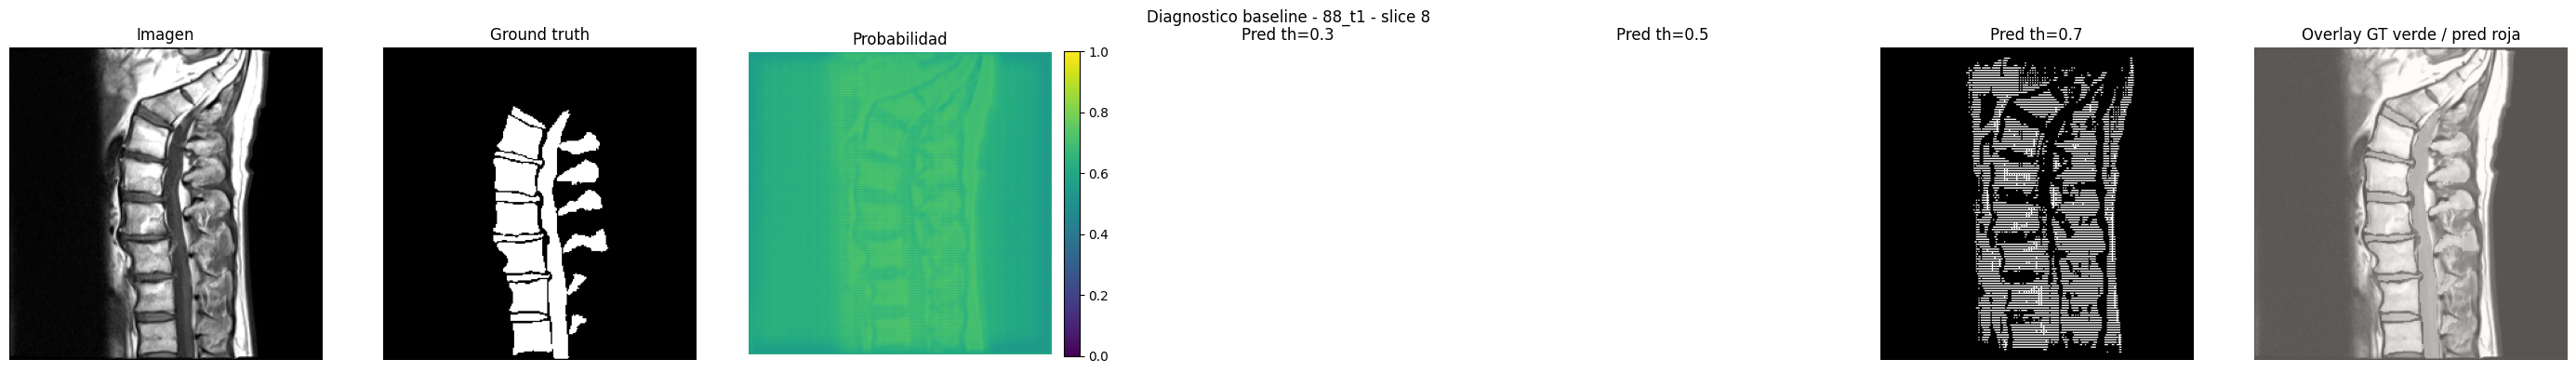

PNG diagnostico thresholds: /content/drive/MyDrive/PFI_MVP/figures/E5_threshold_diagnostic_example.png


In [13]:
example_item = inference_cache[0]
image = example_item["image"]
gt = example_item["mask"]
probs = example_item["probs"]

pred_03 = (probs >= 0.3).astype(np.float32)
pred_05 = (probs >= 0.5).astype(np.float32)
pred_07 = (probs >= 0.7).astype(np.float32)

fig, axes = plt.subplots(1, 7, figsize=(28, 4))

axes[0].imshow(image, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Imagen")

axes[1].imshow(gt, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Ground truth")

im = axes[2].imshow(probs, cmap="viridis", vmin=0, vmax=1)
axes[2].set_title("Probabilidad")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

axes[3].imshow(pred_03, cmap="gray", vmin=0, vmax=1)
axes[3].set_title("Pred th=0.3")

axes[4].imshow(pred_05, cmap="gray", vmin=0, vmax=1)
axes[4].set_title("Pred th=0.5")

axes[5].imshow(pred_07, cmap="gray", vmin=0, vmax=1)
axes[5].set_title("Pred th=0.7")

axes[6].imshow(image, cmap="gray", vmin=0, vmax=1)
axes[6].imshow(np.ma.masked_where(gt == 0, gt), cmap="Greens", alpha=0.45)
axes[6].imshow(np.ma.masked_where(pred_05 == 0, pred_05), cmap="Reds", alpha=0.35)
axes[6].set_title("Overlay GT verde / pred roja")

for ax in axes:
    ax.axis("off")

fig.suptitle(f"Diagnostico baseline - {example_item['case_id']} - slice {example_item['slice_index']}")
fig.tight_layout()

threshold_diagnostic_png_path = FIGURES_ROOT / "E5_threshold_diagnostic_example.png"
fig.savefig(threshold_diagnostic_png_path, dpi=150, bbox_inches="tight")
plt.show()

print("PNG diagnostico thresholds:", threshold_diagnostic_png_path)

## 10. Histograma de probabilidades

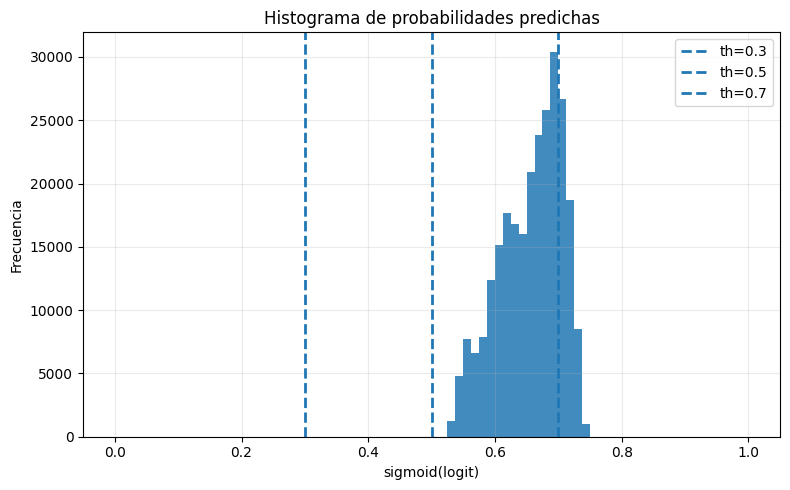

PNG histograma probabilidades: /content/drive/MyDrive/PFI_MVP/figures/E5_probability_histogram.png


In [14]:
all_probs = np.concatenate([item["probs"].ravel() for item in inference_cache])

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.hist(all_probs, bins=80, range=(0, 1), alpha=0.85)
for threshold in [0.3, 0.5, 0.7]:
    ax.axvline(threshold, linestyle="--", linewidth=2, label=f"th={threshold}")
ax.set_title("Histograma de probabilidades predichas")
ax.set_xlabel("sigmoid(logit)")
ax.set_ylabel("Frecuencia")
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()

probability_histogram_png_path = FIGURES_ROOT / "E5_probability_histogram.png"
fig.savefig(probability_histogram_png_path, dpi=150, bbox_inches="tight")
plt.show()

print("PNG histograma probabilidades:", probability_histogram_png_path)

## 11. Diagnostico automatico

In [15]:
def automatic_diagnosis(history_df, baseline_metrics_df, probability_stats_df, threshold_summary_df):
    messages = []

    th05 = threshold_summary_df[np.isclose(threshold_summary_df["threshold"], 0.5)]
    if not th05.empty:
        pred_fg_05 = float(th05["pred_foreground_ratio_mean"].iloc[0])
        if pred_fg_05 > 0.80:
            messages.append("Posible colapso a foreground: con threshold 0.5 se predice mas del 80% de pixeles como positivos.")
        if pred_fg_05 < 0.01:
            messages.append("Posible colapso a background: con threshold 0.5 se predice menos del 1% de pixeles como positivos.")

    mean_prob = float(probability_stats_df["probs_mean"].mean())
    std_prob = float(probability_stats_df["probs_std"].mean())
    if 0.45 <= mean_prob <= 0.55 and std_prob < 0.10:
        messages.append("Probabilidades cerca de 0.5 con baja dispersion: modelo poco calibrado o poco entrenado.")

    if {"train_loss", "val_loss"}.issubset(history_df.columns) and len(history_df) >= 2:
        train_loss_delta = float(history_df["train_loss"].iloc[-1] - history_df["train_loss"].iloc[0])
        val_loss_delta = float(history_df["val_loss"].iloc[-1] - history_df["val_loss"].iloc[0])
        if train_loss_delta < 0 and val_loss_delta > 0:
            messages.append("Sobreajuste probable: train_loss baja mientras val_loss sube.")

    if "val_dice" in history_df.columns and history_df["val_dice"].nunique() <= 1:
        messages.append("Val Dice constante: posible problema de threshold, prediccion saturada o validacion demasiado pequena.")

    best_dice = float(threshold_summary_df["dice_mean"].max())
    dice_05 = float(th05["dice_mean"].iloc[0]) if not th05.empty else np.nan
    if not np.isnan(dice_05) and best_dice - dice_05 > 0.05:
        messages.append("El threshold operativo influye de forma relevante: conviene revisar el mejor threshold antes de cambiar arquitectura.")

    if not messages:
        messages.append("No se detecta un modo de fallo trivial con las reglas automaticas; revisar visualizaciones y ampliar validacion.")

    return messages


diagnosis_messages = automatic_diagnosis(
    history_df=history_df,
    baseline_metrics_df=baseline_metrics_df,
    probability_stats_df=probability_stats_df,
    threshold_summary_df=threshold_summary_df,
)

print("Diagnostico automatico:")
for msg in diagnosis_messages:
    print("-", msg)

Diagnostico automatico:
- Posible colapso a foreground: con threshold 0.5 se predice mas del 80% de pixeles como positivos.
- Sobreajuste probable: train_loss baja mientras val_loss sube.
- Val Dice constante: posible problema de threshold, prediccion saturada o validacion demasiado pequena.
- El threshold operativo influye de forma relevante: conviene revisar el mejor threshold antes de cambiar arquitectura.


## 12. Reporte JSON

In [16]:
th05_summary = threshold_summary_df[np.isclose(threshold_summary_df["threshold"], 0.5)].iloc[0]

diagnostic_report = {
    "evaluated_cases": int(len(inference_cache)),
    "thresholds": THRESHOLDS,
    "best_threshold_by_dice": best_threshold_dice,
    "best_threshold_by_iou": best_threshold_iou,
    "mean_dice_threshold_05": float(th05_summary["dice_mean"]),
    "mean_iou_threshold_05": float(th05_summary["iou_mean"]),
    "mean_gt_foreground_ratio": float(th05_summary["gt_foreground_ratio_mean"]),
    "mean_pred_foreground_ratio_threshold_05": float(th05_summary["pred_foreground_ratio_mean"]),
    "mean_probability": float(probability_stats_df["probs_mean"].mean()),
    "mean_probability_std": float(probability_stats_df["probs_std"].mean()),
    "diagnosis": diagnosis_messages,
    "exports": {
        "probability_stats_csv": str(probability_stats_csv_path),
        "threshold_diagnostics_csv": str(threshold_diagnostics_csv_path),
        "threshold_summary_csv": str(threshold_summary_csv_path),
        "threshold_diagnostic_png": str(threshold_diagnostic_png_path),
        "probability_histogram_png": str(probability_histogram_png_path),
    },
}

diagnostic_report_json_path = BASELINE_ROOT / "E5_diagnostic_report.json"
diagnostic_report_json_path.write_text(json.dumps(diagnostic_report, indent=2), encoding="utf-8")

print("Reporte JSON:", diagnostic_report_json_path)
print(json.dumps(diagnostic_report, indent=2))

Reporte JSON: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_diagnostic_report.json
{
  "evaluated_cases": 4,
  "thresholds": [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9
  ],
  "best_threshold_by_dice": 0.7,
  "best_threshold_by_iou": 0.7,
  "mean_dice_threshold_05": 0.23635954346485513,
  "mean_iou_threshold_05": 0.1343536376966334,
  "mean_gt_foreground_ratio": 0.1343536376953125,
  "mean_pred_foreground_ratio_threshold_05": 1.0,
  "mean_probability": 0.6557530462741852,
  "mean_probability_std": 0.04828596580773592,
  "diagnosis": [
    "Posible colapso a foreground: con threshold 0.5 se predice mas del 80% de pixeles como positivos.",
    "Sobreajuste probable: train_loss baja mientras val_loss sube.",
    "Val Dice constante: posible problema de threshold, prediccion saturada o validacion demasiado pequena.",
    "El threshold operativo influye de forma relevante: conviene revisar el mejor threshold antes de cambiar arquitectura

## 13. Conclusion tecnica Markdown

In [17]:
def build_recommendations(diagnosis_messages, best_threshold_dice, best_threshold_iou):
    text = " ".join(diagnosis_messages).lower()
    recommendations = []

    if "foreground" in text or "background" in text:
        recommendations.append("Revisar funcion de perdida, balance de clases, sampling de slices y threshold operativo.")
    if "sobreajuste" in text:
        recommendations.append("Aumentar cantidad de datos, agregar augmentations y repetir entrenamiento usando GPU si esta disponible.")
    if best_threshold_dice != 0.5 or best_threshold_iou != 0.5:
        recommendations.append("Evaluar un threshold operativo distinto de 0.5 antes de modificar la arquitectura.")
    if len(inference_cache) < 10:
        recommendations.append("Ampliar el conjunto de validacion para reducir variabilidad de las metricas.")

    recommendations.append("Si el pipeline queda validado, crear `05_E5_baseline_mejorado_binario.ipynb` para probar mejoras controladas.")
    return recommendations


recommendations = build_recommendations(diagnosis_messages, best_threshold_dice, best_threshold_iou)

conclusion_md = f"""# Conclusion tecnica - E5 Diagnostico del baseline binario

## Objetivo

Se diagnostico el baseline binario 2D entrenado en `03_E5_baseline_segmentacion_sagital.ipynb`, sin reentrenar ni modificar el modelo principal.

## Evidencia del baseline original

- Modelo evaluado: `{MODEL_PATH}`
- History original: `{HISTORY_CSV}`
- Metricas originales: `{METRICS_CSV}`
- Dice promedio original reportado: {baseline_metrics_df['dice'].mean():.4f}
- IoU promedio original reportado: {baseline_metrics_df['iou'].mean():.4f}

## Resultados por threshold

- Mejor threshold por Dice promedio: {best_threshold_dice}
- Mejor threshold por IoU promedio: {best_threshold_iou}
- Dice promedio con threshold 0.5: {diagnostic_report['mean_dice_threshold_05']:.4f}
- IoU promedio con threshold 0.5: {diagnostic_report['mean_iou_threshold_05']:.4f}
- Foreground promedio GT: {diagnostic_report['mean_gt_foreground_ratio']:.4f}
- Foreground promedio predicho con threshold 0.5: {diagnostic_report['mean_pred_foreground_ratio_threshold_05']:.4f}

## Interpretacion automatica

{chr(10).join("- " + msg for msg in diagnosis_messages)}

## Evidencias exportadas

- Stats de probabilidades: `{probability_stats_csv_path}`
- Diagnostico por threshold: `{threshold_diagnostics_csv_path}`
- Resumen por threshold: `{threshold_summary_csv_path}`
- Figura diagnostica: `{threshold_diagnostic_png_path}`
- Histograma de probabilidades: `{probability_histogram_png_path}`
- Reporte JSON: `{diagnostic_report_json_path}`

## Limitaciones

- Validacion pequena reconstruida desde la misma semilla y seleccion del notebook 03.
- Segmentacion binaria.
- Evaluacion sobre un unico slice sagital por volumen.
- No se evalua multiclase, axial, nnU-Net ni integracion backend.

## Recomendaciones para el proximo paso

{chr(10).join("- " + rec for rec in recommendations)}
"""

conclusion_md_path = DOCS_ROOT / "E5_diagnostico_baseline_binario_conclusion.md"
conclusion_md_path.write_text(conclusion_md, encoding="utf-8")

print(conclusion_md)
print("Conclusion Markdown:", conclusion_md_path)

# Conclusion tecnica - E5 Diagnostico del baseline binario

## Objetivo

Se diagnostico el baseline binario 2D entrenado en `03_E5_baseline_segmentacion_sagital.ipynb`, sin reentrenar ni modificar el modelo principal.

## Evidencia del baseline original

- Modelo evaluado: `/content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_simple_unet2d_baseline.pt`
- History original: `/content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_training_history.csv`
- Metricas originales: `/content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital/E5_baseline_metrics.csv`
- Dice promedio original reportado: 0.2364
- IoU promedio original reportado: 0.1344

## Resultados por threshold

- Mejor threshold por Dice promedio: 0.7
- Mejor threshold por IoU promedio: 0.7
- Dice promedio con threshold 0.5: 0.2364
- IoU promedio con threshold 0.5: 0.1344
- Foreground promedio GT: 0.1344
- Foreground promedio predicho con threshold 0.5: 1.0000

## Interpretacion automatica

- Posible colapso a for

## 14. Cierre

Este notebook solo diagnostica el comportamiento de inferencia del baseline binario. Las mejoras deben implementarse en una etapa posterior, idealmente en `05_E5_baseline_mejorado_binario.ipynb`.